# IE 7615 — Milestone 2: YOLOv8 Object Detection

## Objective
This notebook trains and evaluates a YOLOv8 object detection model on the Milestone 2 multi-object dataset.

### Pipeline
1. Verify GPU availability
2. Clone the project repository
3. Rebuild the dataset reproducibly
4. Validate the YOLO dataset
5. Install Ultralytics
6. Load a pretrained YOLOv8 model
7. Run a 1-epoch smoke test
8. Proceed to full training only after the smoke test passes

### Dataset
- 73 object classes
- 400 multi-object composite images
- 4 objects per image
- 1,600 bounding-box annotations
- Train: 280 images
- Validation: 60 images
- Test: 60 images
- Random seed: 42

## 1. Verify GPU Environment

YOLO training will be performed on a GPU in Google Colab.

This cell verifies:
- PyTorch version
- CUDA availability
- Assigned GPU model

In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available.")

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


## 2. Clone the Project Repository

The repository contains:
- Original single-object dataset
- Object ID mapping
- Dataset auditing scripts
- Leakage-safe source splitting
- Multi-object dataset generation
- YOLO dataset configuration
- Dataset validation scripts

The generated detection dataset is intentionally not stored in GitHub because it can be reproduced from code.

In [3]:
# Clone the latest version of the project repository.
!git clone https://github.com/pjraghuram/IE7615-Deep-Learning-for-AI.git

# Move into the repository.
%cd IE7615-Deep-Learning-for-AI

Cloning into 'IE7615-Deep-Learning-for-AI'...
remote: Enumerating objects: 7435, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 7435 (delta 5), reused 24 (delta 5), pack-reused 7409 (from 1)
Receiving objects: 100% (7435/7435), 158.49 MiB | 22.04 MiB/s, done.
Resolving deltas: 100% (36/36), done.
Updating files: 100% (7373/7373), done.
/content/IE7615-Deep-Learning-for-AI


In [4]:
# Confirm the active Git branch and available Milestone 2 scripts.
!git branch
!ls milestone2/src

* main
audit_source_dataset.py  generate_composites.py     validate_yolo_dataset.py
create_source_splits.py  generate_final_dataset.py  visualize_annotations.py


## 3. Audit the Original Source Dataset

Before generating the detection dataset, the original single-object dataset is audited.

The audit verifies:
- 73 object classes are present
- Object IDs match `OBJ001` through `OBJ073`
- Image formats are recognized
- Background-only images are identified
- Exact duplicates are detected
- Object IDs and source folders are consistent

No source images are modified during this step.

In [5]:
!python milestone2/src/audit_source_dataset.py


SOURCE DATASET AUDIT
Class folders:           73
CSV class mappings:      73
Total image files:       7343
Object images:           6958
Background-only images:  385

Extensions:
  .jpeg: 207
  .jpg: 7136

Per-class total image range:
  Minimum: 100
  Maximum: 113

Per-class object-image range:
  Minimum: 90
  Maximum: 106

Background-image range:
  Minimum: 0
  Maximum: 11

Exact duplicate check:
  Duplicate hash groups: 28
  Extra duplicate files: 28

Filename checks:
  All filenames contain a recognizable OBJ ID.
  Folder/filename class IDs agree.

Class ID validation: PASS

Manifest saved to:
  milestone2/metadata/source_manifest.csv

Audit complete.


## 4. Create Leakage-Safe Source Splits

The original single-object images are split before generating composite images.

This is critical because the assignment requires that no source image appear in more than one of:
- training
- validation
- test

The script:
- excludes background-only images from object candidates
- removes exact duplicate object images
- creates deterministic train/validation/test source assignments
- uses random seed 42
- verifies that no source path or duplicate hash crosses splits

In [6]:
!python milestone2/src/create_source_splits.py


SOURCE SPLIT CREATION
All source images:        7343
Object-image candidates:  6958
Background images ignored: 385
Unique object images:     6942
Duplicate object files:   16

Split counts:
  Train: 4823
  Val:   1019
  Test:  1100
  Total: 6942

Unique object images per class:
  Minimum: 89
  Maximum: 106

Leakage checks:
  Source path overlap: PASS
  Exact duplicate overlap: PASS
  All 73 classes in train: PASS
  All 73 classes in val:   PASS
  All 73 classes in test:  PASS

Configuration:
  Ratios: 0.70 / 0.15 / 0.15
  Random seed: 42

Files created:
  milestone2/metadata/source_split_manifest.csv
  milestone2/metadata/duplicate_report.csv

Source split creation complete.


## 5. Generate the Final Multi-Object Dataset

The final detection dataset contains 400 composite images.

### Generation design
- 4 group members
- 400 composite images total
- 100 generated composites allocated to each group member in the generation manifest
- 4 different object classes per composite
- 640 × 640 output size
- 2 × 2 image grid
- 4 bounding-box annotations per image
- fixed random seed 42

### Bounding-box definition

Each composite is constructed as a 2 × 2 grid of four source images. Because each source image represents one assigned object class, the known boundaries of each 320 × 320 tile are used as the YOLO bounding box for that class.

Therefore, the annotations represent the spatial region occupied by each constituent source image rather than a tightly drawn bounding box around the physical object inside that source image. This deterministic annotation strategy follows the composite-image construction used in this milestone and should be considered when interpreting localization metrics.

### Final split
- Train: 280 images
- Validation: 60 images
- Test: 60 images

Class sampling is balanced so that all 73 classes receive similar representation within each split.

In [7]:
!python milestone2/src/generate_final_dataset.py


FINAL MILESTONE 2 DATASET GENERATION

Generating images for: Hemanth Rajaboyina

Generating images for: Jaya Raghu Ram Penugonda

Generating images for: Nikhil Kudupudi

Generating images for: Sri Lakshmi Swetha Jalluri

Dataset summary:
  Train composites: 280
  Val composites:   60
  Test composites:  60
  Total composites: 400
  Total annotations: 1600

Per-student generation:
  Hemanth Rajaboyina: 100
  Jaya Raghu Ram Penugonda: 100
  Nikhil Kudupudi: 100
  Sri Lakshmi Swetha Jalluri: 100

Class-balance check:
  train: min=15, max=16
  val: min=3, max=4
  test: min=3, max=4

Integrity checks:
  No source reuse: PASS
  No MD5 reuse: PASS
  Four unique classes/image: PASS
  Four annotations/image: PASS
  Student minimum requirement: PASS

Reproducibility:
  Random seed: 42

Metadata files:
  milestone2/metadata/composite_manifest.csv
  milestone2/metadata/class_distribution.csv

Final dataset generation complete.


## 6. Validate the Final YOLO Dataset

Before training, the final generated files are independently validated.

The validator checks:
- image and label counts
- one-to-one image/label pairing
- four annotations per image
- valid YOLO label format
- normalized bounding-box coordinates
- valid class IDs from 0 through 72
- all 73 classes represented in train, validation, and test

In [8]:
!python milestone2/src/validate_yolo_dataset.py


YOLO DATASET VALIDATION
Dataset root: /content/IE7615-Deep-Learning-for-AI/milestone2/data/generated
Classes:      73

TRAIN
  Images:       280
  Labels:       280
  Boxes:        1120
  Class range:  15–16
  Pairing:      PASS
  Label format: PASS
  Class cover:  PASS

VAL
  Images:       60
  Labels:       60
  Boxes:        240
  Class range:  3–4
  Pairing:      PASS
  Label format: PASS
  Class cover:  PASS

TEST
  Images:       60
  Labels:       60
  Boxes:        240
  Class range:  3–4
  Pairing:      PASS
  Label format: PASS
  Class cover:  PASS

GLOBAL SUMMARY
  Images:       400
  Label files:  400
  Bounding boxes: 1600
  Classes:      73

FINAL CHECKS
  data.yaml:          PASS
  Image-label pairs:  PASS
  YOLO format:        PASS
  Coordinate ranges:  PASS
  Class IDs 0–72:     PASS
  All classes present: PASS

YOLO dataset validation complete.


## 7. Install Ultralytics

Ultralytics provides the YOLOv8 implementation used for Milestone 2.

The package is installed only after the dataset passes all validation checks.

In [9]:
# Install the exact Ultralytics version used for the reported experiments
# to improve reproducibility.
!pip install -q ultralytics==8.4.174

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 229.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 10.0 MB/s eta 0:00:00


In [10]:
import ultralytics

print("Ultralytics version:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics version: 8.4.174


## 8. Load YOLOv8 Nano

For the initial smoke test, we use the pretrained `yolov8n.pt` model.

YOLOv8 Nano is selected because:
- it is lightweight
- it initializes quickly
- it is suitable for verifying the complete training pipeline
- this run is only a technical smoke test, not the final experiment

In [11]:
from ultralytics import YOLO

# Explicitly load a YOLOv8 model as required by the assignment.
model = YOLO("yolov8n.pt")

print("YOLOv8 Nano loaded successfully.")

YOLOv8 Nano loaded successfully.


## 9. Run a 1-Epoch Smoke Test

This run is not used as the final experiment.

Its only purpose is to verify that:
- YOLOv8 reads the dataset configuration correctly
- all 73 configured classes are loaded correctly
- training images and labels load successfully
- GPU training works
- validation runs without errors
- training outputs are saved correctly

Only after this test passes should the full training configuration be used.

In [12]:
results = model.train(
    data="milestone2/configs/data.yaml",

    # Smoke test only.
    epochs=1,

    # Dataset images were generated at 640 x 640.
    imgsz=640,

    # Conservative batch size for broad Colab GPU compatibility.
    batch=16,

    # Use the first CUDA GPU.
    device=0,

    # Small worker count is generally stable in Colab.
    workers=2,

    # Save outputs inside the project structure.
    project="milestone2/results/runs",
    name="yolov8n_smoke_test",

    # Reproducibility.
    seed=42,
    deterministic=True,
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=milestone2/configs/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_smoke_test, nbs=64, nms=None, opset=None, optimize=Fa

## 10. Smoke Test Acceptance Criteria

The smoke test is considered successful only if:

- YOLOv8 correctly loads all 73 configured classes from `data.yaml`
- the 280 training images load successfully
- the 60 validation images load successfully
- bounding-box labels are accepted without warnings or format errors
- one complete training epoch finishes
- validation completes
- model outputs are saved successfully

If the smoke test passes, the next stage is the full YOLOv8 training experiment.

## 11. YOLOv8 Nano Pilot Training

The 1-epoch smoke test confirmed that the complete training pipeline works correctly.

A 10-epoch pilot experiment is now performed to verify that the model begins learning meaningful object detection patterns before committing to a longer final training run.

### Configuration
- Model: YOLOv8 Nano
- Pretrained weights: `yolov8n.pt`
- Epochs: 10
- Input size: 640 × 640
- Batch size: 16
- GPU: NVIDIA Tesla T4
- Random seed: 42

The purpose of this experiment is to observe whether precision, recall, mAP@0.5, and mAP@0.5:0.95 improve beyond the initial smoke-test values.

In [13]:
from ultralytics import YOLO

# Start again from the original pretrained YOLOv8 Nano weights.
pilot_model = YOLO("yolov8n.pt")

In [14]:
pilot_results = pilot_model.train(
    data="milestone2/configs/data.yaml",

    # Short pilot run to confirm learning behavior.
    epochs=10,

    # Keep the same resolution as the generated dataset.
    imgsz=640,

    # Suitable for the Tesla T4 used by this Colab runtime.
    batch=16,

    # Use GPU.
    device=0,

    workers=2,

    # Save this experiment separately from the smoke test.
    project="milestone2/results/runs",
    name="yolov8n_pilot_10epochs",

    # Reproducibility.
    seed=42,
    deterministic=True,

    # Validate after training.
    val=True,

    # Save training plots and metrics.
    plots=True,
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=milestone2/configs/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_pilot_10epochs, nbs=64, nms=None, opset=None, optimi

## 12. Pilot Training Result

The 10-epoch YOLOv8 Nano pilot completed successfully.

The validation metrics improved progressively during training, confirming that the model is learning from the generated detection dataset.

### Epoch 10 validation
- Precision: ~0.036
- Recall: ~0.676
- mAP@0.5: ~0.101
- mAP@0.5:0.95: ~0.101

The pilot was used only to verify learning behavior. These values are not treated as the final project results.

Because performance was still improving at epoch 10, a longer training run is required for the final model.

## 13. Full YOLOv8 Nano Training

The 10-epoch pilot confirmed that YOLOv8 is learning from the generated dataset.

The pretrained YOLOv8 Nano checkpoint (`yolov8n.pt`) is fine-tuned on the custom 73-class Milestone 2 dataset rather than trained from random initialization.

The same YOLOv8 Nano configuration is now trained for a longer period.

### Training configuration
- Model: YOLOv8 Nano
- Pretrained weights: `yolov8n.pt`
- Maximum epochs: 50
- Image size: 640 × 640
- Batch size: 16
- Device: NVIDIA Tesla T4 GPU
- Optimizer: Ultralytics automatic selection
- Random seed: 42
- Early stopping patience: 10 epochs

Ultralytics default training augmentations were retained. No additional custom augmentation hyperparameters were introduced for the model comparison.

Validation performance is used to select the best checkpoint. The held-out test set is not used during model training or model selection.

In [15]:
from pathlib import Path
from ultralytics import YOLO

# Start the full experiment from the original pretrained YOLOv8 Nano weights.
final_model = YOLO("yolov8n.pt")

# Use an absolute output directory so results are stored predictably.
RUNS_DIR = Path.cwd() / "milestone2" / "results" / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("Training outputs will be saved to:")
print(RUNS_DIR)

Training outputs will be saved to:
/content/IE7615-Deep-Learning-for-AI/milestone2/results/runs


In [16]:
final_results = final_model.train(
    data="milestone2/configs/data.yaml",

    # Maximum number of training epochs.
    epochs=50,

    # Stop if validation performance does not improve
    # for 10 consecutive epochs.
    patience=10,

    # Match the generated composite resolution.
    imgsz=640,

    # Suitable for the Tesla T4.
    batch=16,

    # Train on the Colab GPU.
    device=0,

    workers=2,

    # Keep this run separate from smoke-test and pilot outputs.
    project=str(RUNS_DIR),
    name="yolov8n_final_50epochs",

    # Reproducibility.
    seed=42,
    deterministic=True,

    # Run validation and save plots/results.
    val=True,
    plots=True,
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=milestone2/configs/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_final_50epochs, nbs=64, nms=None, opset=None, optimi

## 14. YOLOv8 Small Comparison

The YOLOv8 Nano model achieved strong validation performance after 50 epochs.

To evaluate whether a larger YOLOv8 variant can improve detection performance, the pretrained YOLOv8 Small checkpoint (`yolov8s.pt`) is fine-tuned on the same custom 73-class Milestone 2 dataset.

The same dataset, image size, batch size, random seed, validation procedure, and early-stopping strategy are used to keep the comparison as consistent as possible.

### Comparison goal
YOLOv8 Nano and YOLOv8 Small are compared using validation metrics only:

- Precision
- Recall
- mAP@0.5
- mAP@0.5:0.95
- Training time
- Model size / parameter count

The held-out test set remains unused during model comparison and is evaluated only after the final model is selected.

In [17]:
from pathlib import Path
from ultralytics import YOLO

# Load pretrained YOLOv8 Small weights.
yolov8s_model = YOLO("yolov8s.pt")

RUNS_DIR = Path.cwd() / "milestone2" / "results" / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("YOLOv8 Small loaded successfully.")
print("Training outputs will be saved to:")
print(RUNS_DIR)

YOLOv8 Small loaded successfully.
Training outputs will be saved to:
/content/IE7615-Deep-Learning-for-AI/milestone2/results/runs


In [18]:
yolov8s_results = yolov8s_model.train(
    data="milestone2/configs/data.yaml",

    # Same maximum epochs as YOLOv8 Nano.
    epochs=50,

    # Same early stopping setting.
    patience=10,

    # Same input resolution.
    imgsz=640,

    # Start with the same batch size for fair comparison.
    batch=16,

    # Use GPU.
    device=0,

    workers=2,

    # Save this experiment separately.
    project=str(RUNS_DIR),
    name="yolov8s_final_50epochs",

    # Reproducibility.
    seed=42,
    deterministic=True,

    # Validate during training.
    val=True,

    # Save plots and metrics.
    plots=True,
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=milestone2/configs/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_final_50epochs, nbs=64, nms=None, opset=None, optimi

## 15. YOLOv8 Nano vs YOLOv8 Small

The two YOLOv8 variants are compared using validation performance.

The test set is still held out and is not used for model selection.

## 16. Final Model Selection

YOLOv8 Nano and YOLOv8 Small were compared using validation performance only.

YOLOv8 Small achieved substantially better validation performance across precision, recall, and mean Average Precision while maintaining a reasonable model size and training time.

### Validation comparison

| Model | Precision | Recall | mAP@0.5 | mAP@0.5:0.95 |
|---|---:|---:|---:|---:|
| YOLOv8 Nano | 0.738 | 0.596 | 0.703 | 0.701 |
| YOLOv8 Small | 0.818 | 0.848 | 0.902 | 0.902 |

YOLOv8 Small was therefore selected as the final model.

The held-out test set has not been used for model selection or hyperparameter tuning. It is evaluated only after the final model has been selected.

## 17. Final Evaluation on the Held-Out Test Set

The final selected model, YOLOv8 Small, is evaluated on the held-out test split.

The test set was not used during training, hyperparameter tuning, or model selection.

### Test set
- 60 composite images
- 240 object annotations
- 73 object classes

This evaluation provides the final held-out performance estimate reported for Milestone 2.

In [19]:
from pathlib import Path
from ultralytics import YOLO

# Path to the best checkpoint selected using validation performance.
BEST_MODEL_PATH = (
    Path.cwd()
    / "milestone2"
    / "results"
    / "runs"
    / "yolov8s_final_50epochs"
    / "weights"
    / "best.pt"
)

print("Final model:")
print(BEST_MODEL_PATH)

# Load the selected best YOLOv8 Small checkpoint.
best_model = YOLO(str(BEST_MODEL_PATH))

Final model:
/content/IE7615-Deep-Learning-for-AI/milestone2/results/runs/yolov8s_final_50epochs/weights/best.pt


In [20]:
# Evaluate the selected model once on the held-out test set.
test_results = best_model.val(
    data="milestone2/configs/data.yaml",

    # Explicitly evaluate the test split.
    split="test",

    # Same image resolution used during training.
    imgsz=640,

    # Use the Colab GPU.
    device=0,

    batch=16,
    workers=2,

    # Save evaluation plots and predictions.
    plots=True,

    project=str(
        Path.cwd()
        / "milestone2"
        / "results"
        / "runs"
    ),

    name="yolov8s_final_test",
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,153,835 parameters, 0 gradients, 28.6 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 22.2±15.1 MB/s, size: 125.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/IE7615-Deep-Learning-for-AI/milestone2/data/generated/labels/test... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 316.2it/s 0.2s
val: New cache created: /content/IE7615-Deep-Learning-for-AI/milestone2/data/generated/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.4it/s 2.8s
                   all         60        240      0.794      0.786      0.851      0.851
            Basketball          4          4          1      0.921      0.995      0.995
          Water bottl

In [21]:
print("\nFINAL TEST RESULTS")
print("-" * 40)

print(f"Precision:      {test_results.box.mp:.4f}")
print(f"Recall:         {test_results.box.mr:.4f}")
print(f"mAP@0.5:        {test_results.box.map50:.4f}")
print(f"mAP@0.5:0.95:   {test_results.box.map:.4f}")


FINAL TEST RESULTS
----------------------------------------
Precision:      0.7937
Recall:         0.7856
mAP@0.5:        0.8510
mAP@0.5:0.95:   0.8510


## 18. Final Test Results

The selected YOLOv8 Small model was evaluated once on the held-out test set after model selection was complete.

### Test performance

| Metric | Test Result |
|---|---:|
| Precision | 0.7937 |
| Recall | 0.7856 |
| mAP@0.5 | 0.8510 |
| mAP@0.5:0.95 | 0.8510 |

The model achieved strong overall performance across the 73 object classes.

The test results are slightly lower than the validation results, which is expected because the test set was not used during training, tuning, or model selection.

The mAP@0.5 and mAP@0.5:0.95 values are nearly identical because the annotations use fixed tile boundaries for each object region. Once the model predicts the correct tile region, the bounding box often overlaps strongly with the ground-truth box across multiple IoU thresholds.

As a result, classification errors contribute more to overall performance differences than localization errors in this dataset design.

These values are used as the final reported performance for the selected YOLOv8 Small detector.

## 19. Inference on Held-Out Multi-Object Test Images

The final YOLOv8 Small model is now used to make predictions on held-out test images.

For each detected object, the model returns:

- Object ID (`OBJ###`)
- Object name
- Confidence score
- Bounding-box location `(x1, y1, x2, y2)`

This demonstrates the required inference output format by returning object identities and bounding-box locations for detected objects in multi-object images. Missed detections and classification errors are analyzed in the following sections.

In [22]:
from pathlib import Path
from ultralytics import YOLO
from IPython.display import display, Image as IPImage

# Load the best YOLOv8 Small checkpoint.
BEST_MODEL_PATH = (
    Path.cwd()
    / "milestone2"
    / "results"
    / "runs"
    / "yolov8s_final_50epochs"
    / "weights"
    / "best.pt"
)

inference_model = YOLO(str(BEST_MODEL_PATH))

# Directory containing held-out test images.
TEST_IMAGE_DIR = (
    Path.cwd()
    / "milestone2"
    / "data"
    / "generated"
    / "images"
    / "test"
)

# Select a few test images for qualitative evaluation.
test_images = sorted(TEST_IMAGE_DIR.glob("test_*.jpg"))[:5]

print(f"Selected {len(test_images)} test images for inference.")

Selected 5 test images for inference.


In [23]:
# Run inference on the selected test images.
prediction_results = inference_model.predict(
    source=[str(path) for path in test_images],

    # Confidence threshold for displayed predictions.
    conf=0.25,

    # Same image size used during training.
    imgsz=640,

    # Use GPU.
    device=0,

    # Save annotated prediction images.
    save=True,

    # Save output in a dedicated folder.
    project=str(
        Path.cwd()
        / "milestone2"
        / "results"
        / "runs"
    ),
    name="final_inference_examples",

    verbose=False,
)

Results saved to /content/IE7615-Deep-Learning-for-AI/milestone2/results/runs/final_inference_examples


In [24]:
print("\nDETECTED OBJECTS")
print("=" * 80)

for result in prediction_results:
    image_name = Path(result.path).name

    print(f"\nImage: {image_name}")
    print("-" * 80)

    if result.boxes is None or len(result.boxes) == 0:
        print("No objects detected.")
        continue

    for box in result.boxes:
        # YOLO class index: 0-72
        class_id = int(box.cls.item())

        # Convert class index to canonical project Object ID.
        # class 0 -> OBJ001, class 72 -> OBJ073
        object_id = f"OBJ{class_id + 1:03d}"

        # Human-readable object name from data.yaml/model names.
        object_name = inference_model.names[class_id]

        # Prediction confidence.
        confidence = float(box.conf.item())

        # Bounding box in pixel coordinates.
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        print(
            f"{object_id:<8} | "
            f"{object_name:<25} | "
            f"confidence={confidence:.3f} | "
            f"bbox=({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})"
        )


DETECTED OBJECTS

Image: test_000001.jpg
--------------------------------------------------------------------------------
OBJ027   | Tennis ball               | confidence=0.974 | bbox=(320.3, 319.6, 640.0, 639.7)
OBJ055   | Scientific Calculator     | confidence=0.402 | bbox=(0.0, 320.1, 320.2, 640.0)
OBJ063   | Measuring Bottle          | confidence=0.350 | bbox=(319.8, 0.0, 639.3, 319.8)

Image: test_000002.jpg
--------------------------------------------------------------------------------
OBJ036   | Pencil case               | confidence=0.999 | bbox=(320.4, 0.0, 639.9, 318.6)
OBJ022   | Guitar                    | confidence=0.983 | bbox=(0.0, 0.0, 320.1, 319.6)
OBJ028   | Banana                    | confidence=0.846 | bbox=(319.8, 320.6, 639.1, 640.0)
OBJ051   | Tissue                    | confidence=0.263 | bbox=(0.0, 320.0, 320.9, 640.0)

Image: test_000003.jpg
--------------------------------------------------------------------------------
OBJ070   | Astronaut projector     

Saved annotated predictions: 5

test_000001.jpg


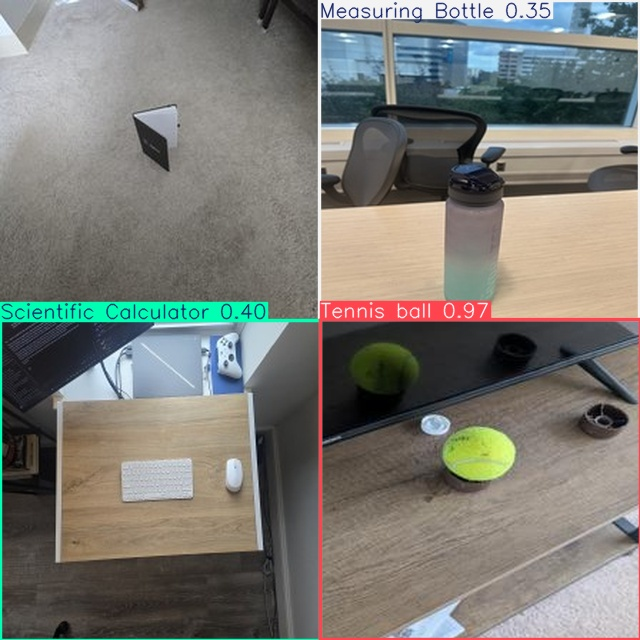


test_000002.jpg


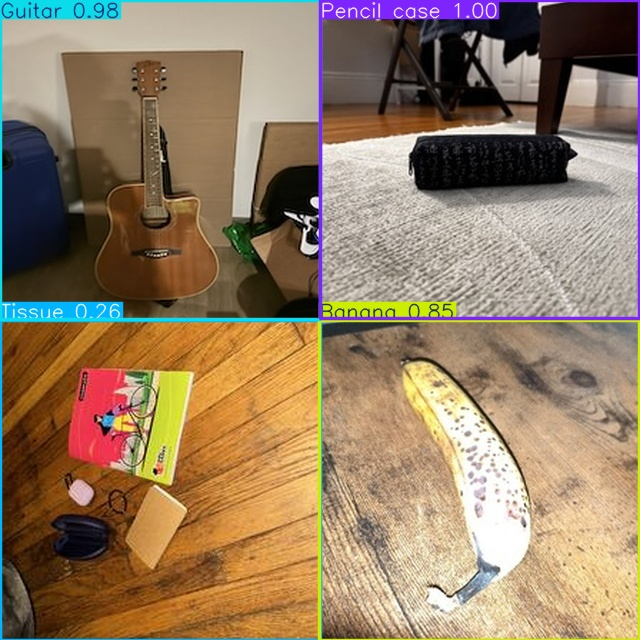


test_000003.jpg


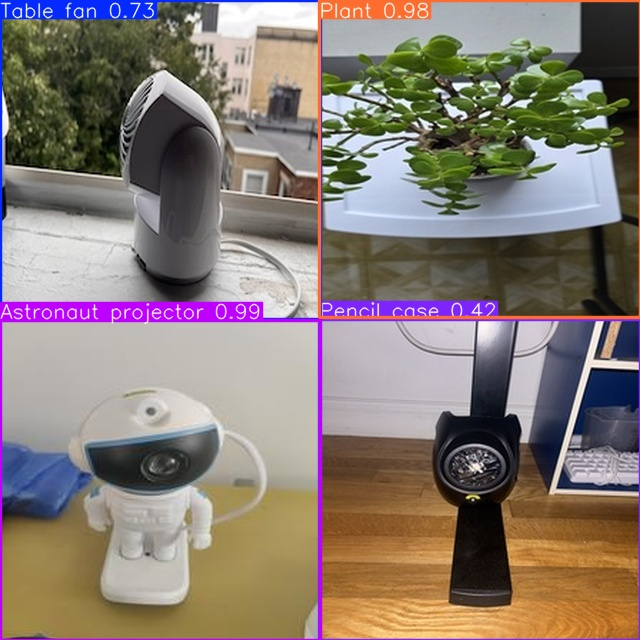


test_000004.jpg


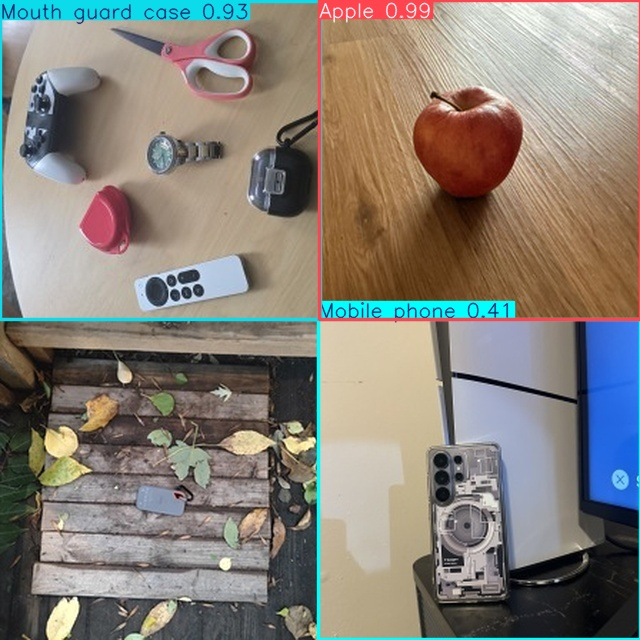


test_000005.jpg


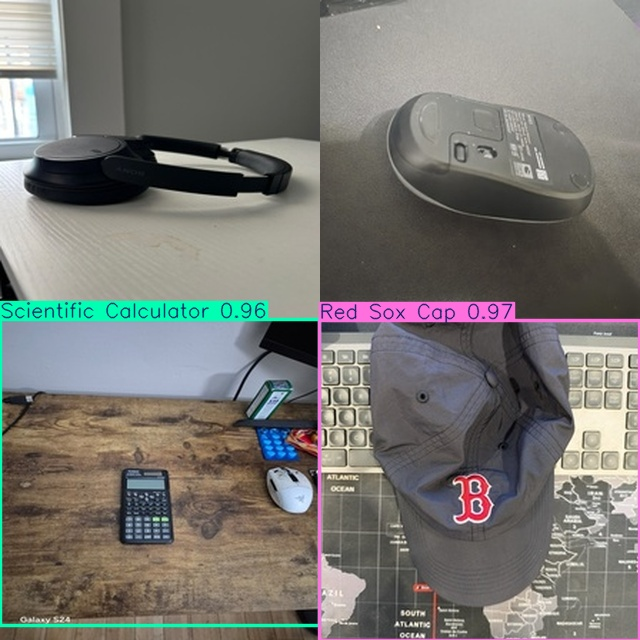

In [25]:
# Locate saved prediction images.
PREDICTION_DIR = (
    Path.cwd()
    / "milestone2"
    / "results"
    / "runs"
    / "final_inference_examples"
)

saved_images = sorted(PREDICTION_DIR.glob("*.jpg"))

print(f"Saved annotated predictions: {len(saved_images)}")

for image_path in saved_images[:5]:
    print(f"\n{image_path.name}")
    display(IPImage(filename=str(image_path)))

## 20. Preliminary Qualitative Detection Results

The final YOLOv8 Small model was applied to a small set of held-out multi-object test images for an initial qualitative inspection.

For each prediction, the inference pipeline returns:

- Canonical Object ID (`OBJ001`–`OBJ073`)
- Human-readable object name
- Prediction confidence
- Pixel-coordinate bounding box `(x1, y1, x2, y2)`

These initial examples show that the model can detect and localize multiple objects within the same composite image. However, some images contain missed detections or incorrect class predictions.

A systematic per-image analysis is performed in the following sections to evaluate all 60 test images and select representative success and failure cases objectively.

## 21. Object-ID Detection Visualization

For clearer qualitative inspection, the model predictions are visualized using the canonical project Object IDs.

Each displayed detection contains:

`OBJ### | Object Name | Confidence`

The corresponding bounding-box coordinates are also retained in the printed inference output.

These visualizations are preliminary examples only. Representative report figures are selected later using the complete per-image evaluation.

In [26]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

# Folder for report-ready prediction visualizations.
ID_VIS_DIR = (
    Path.cwd()
    / "milestone2"
    / "results"
    / "runs"
    / "final_inference_with_ids"
)

ID_VIS_DIR.mkdir(parents=True, exist_ok=True)


def visualize_with_object_ids(result, output_dir):
    """
    Draw YOLO detections using canonical OBJ### IDs,
    object names, confidence scores, and bounding boxes.
    """

    image_path = Path(result.path)
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    if result.boxes is not None:
        for box in result.boxes:
            class_id = int(box.cls.item())

            # Convert YOLO class index to canonical Object ID.
            object_id = f"OBJ{class_id + 1:03d}"

            # Human-readable class name.
            object_name = inference_model.names[class_id]

            # Confidence.
            confidence = float(box.conf.item())

            # Pixel coordinates.
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            # Draw bounding box.
            draw.rectangle(
                [(x1, y1), (x2, y2)],
                outline="red",
                width=4
            )

            # Report-ready label.
            label = f"{object_id} | {object_name} | {confidence:.2f}"

            # Draw label background.
            text_bbox = draw.textbbox((x1, y1), label)
            text_width = text_bbox[2] - text_bbox[0]
            text_height = text_bbox[3] - text_bbox[1]

            label_y = max(0, y1 - text_height - 6)

            draw.rectangle(
                [
                    (x1, label_y),
                    (x1 + text_width + 6, label_y + text_height + 6)
                ],
                fill="white"
            )

            draw.text(
                (x1 + 3, label_y + 3),
                label,
                fill="black"
            )

    output_path = output_dir / image_path.name
    image.save(output_path)

    return output_path


test_000001.jpg


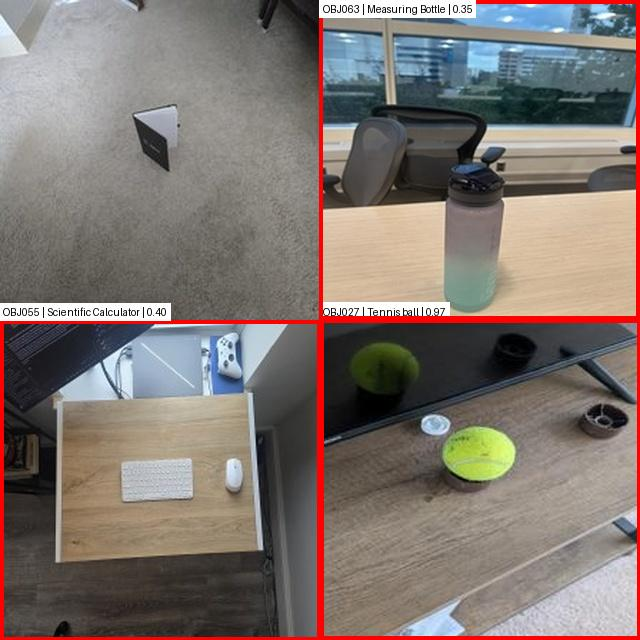


test_000002.jpg


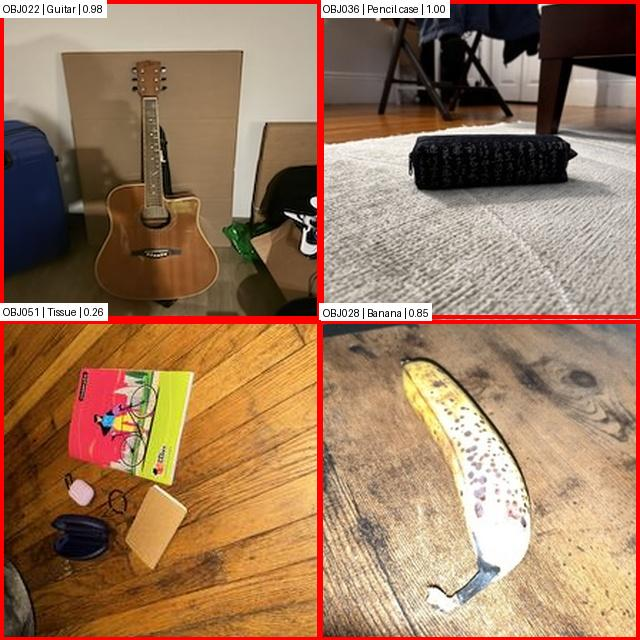


test_000003.jpg


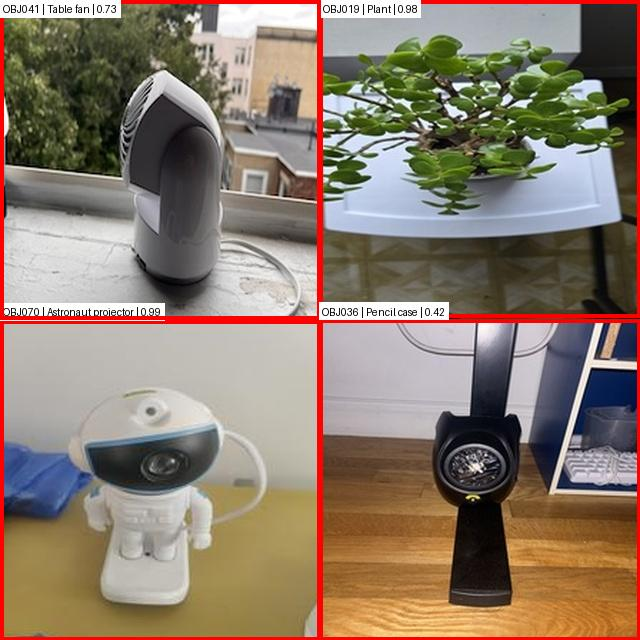


test_000004.jpg


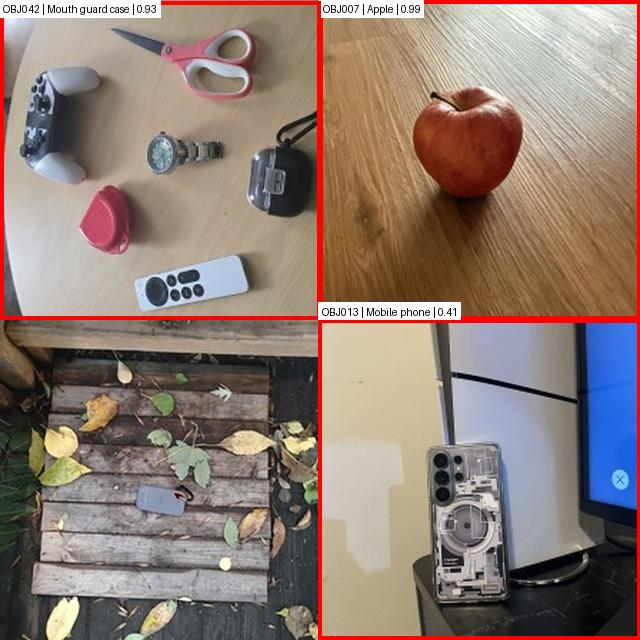


test_000005.jpg


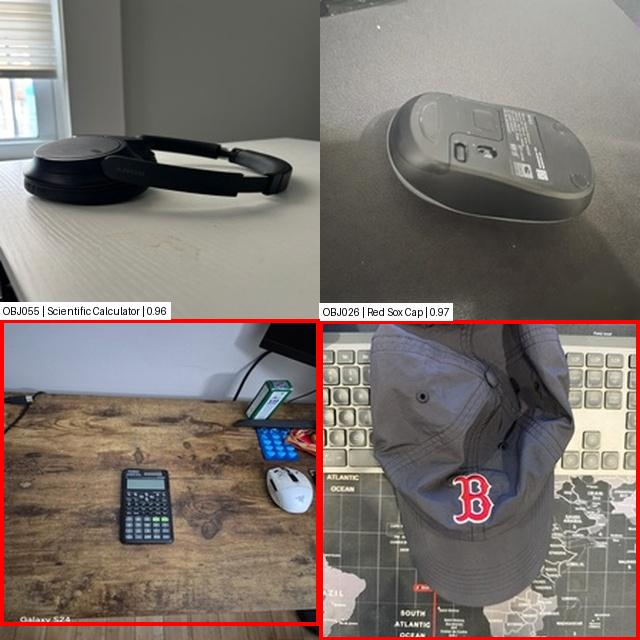

In [27]:
# Generate and display report-ready prediction images.
id_visualizations = []

for result in prediction_results:
    output_path = visualize_with_object_ids(
        result,
        ID_VIS_DIR
    )

    id_visualizations.append(output_path)

    print(f"\n{output_path.name}")
    display(Image.open(output_path))

## 22. Per-Image Detection Analysis

To select representative qualitative examples objectively, predictions are compared with the ground-truth YOLO annotations for every image in the held-out test set.

A prediction is counted as a correct detection when:

- the predicted class matches the ground-truth class, and
- the predicted bounding box has an Intersection over Union (IoU) of at least 0.50 with the corresponding ground-truth box.

For each test image, the analysis reports:

- Number of ground-truth objects
- Number of predictions
- Number of correctly matched objects
- Missed objects
- Incorrect / unmatched predictions

This allows successful and failure examples to be selected based on measured performance rather than manual inspection.

In [28]:
from pathlib import Path

# Collect all held-out test images.
all_test_images = sorted(TEST_IMAGE_DIR.glob("test_*.jpg"))

print(f"Number of test images: {len(all_test_images)}")

# Run inference on the complete test set.
all_test_predictions = inference_model.predict(
    source=[str(path) for path in all_test_images],
    conf=0.25,
    imgsz=640,
    device=0,
    save=False,
    verbose=False,
)

Number of test images: 60


In [29]:
def yolo_to_xyxy(label, image_width, image_height):
    """
    Convert a YOLO-format annotation:
        class_id x_center y_center width height

    from normalized coordinates to pixel-space:
        class_id, x1, y1, x2, y2
    """

    class_id, x_center, y_center, width, height = label

    x_center *= image_width
    y_center *= image_height
    width *= image_width
    height *= image_height

    x1 = x_center - width / 2
    y1 = y_center - height / 2
    x2 = x_center + width / 2
    y2 = y_center + height / 2

    return int(class_id), x1, y1, x2, y2


def calculate_iou(box_a, box_b):
    """
    Calculate Intersection over Union (IoU)
    between two bounding boxes in x1, y1, x2, y2 format.
    """

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    intersection_x1 = max(ax1, bx1)
    intersection_y1 = max(ay1, by1)
    intersection_x2 = min(ax2, bx2)
    intersection_y2 = min(ay2, by2)

    intersection_width = max(0, intersection_x2 - intersection_x1)
    intersection_height = max(0, intersection_y2 - intersection_y1)

    intersection_area = intersection_width * intersection_height

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union_area = area_a + area_b - intersection_area

    if union_area == 0:
        return 0.0

    return intersection_area / union_area

In [30]:
TEST_LABEL_DIR = (
    Path.cwd()
    / "milestone2"
    / "data"
    / "generated"
    / "labels"
    / "test"
)

image_analysis = []

for result in all_test_predictions:
    image_path = Path(result.path)
    image_name = image_path.name

    # Corresponding YOLO ground-truth label file.
    label_path = TEST_LABEL_DIR / f"{image_path.stem}.txt"

    # Images are generated at 640 x 640.
    image_width = result.orig_shape[1]
    image_height = result.orig_shape[0]

    # ---------------------------------------------------------
    # Read ground-truth annotations.
    # ---------------------------------------------------------
    ground_truth = []

    with open(label_path, "r") as file:
        for line in file:
            values = list(map(float, line.strip().split()))
            ground_truth.append(
                yolo_to_xyxy(
                    values,
                    image_width,
                    image_height
                )
            )

    # ---------------------------------------------------------
    # Extract model predictions.
    # ---------------------------------------------------------
    predictions = []

    if result.boxes is not None:
        for box in result.boxes:
            class_id = int(box.cls.item())
            confidence = float(box.conf.item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            predictions.append(
                {
                    "class_id": class_id,
                    "confidence": confidence,
                    "bbox": (x1, y1, x2, y2)
                }
            )

    # ---------------------------------------------------------
    # Match predictions to ground-truth objects.
    # ---------------------------------------------------------
    matched_gt = set()
    matched_predictions = set()

    for pred_index, prediction in enumerate(predictions):

        best_gt_index = None
        best_iou = 0.0

        for gt_index, gt in enumerate(ground_truth):

            # Do not match the same ground-truth object twice.
            if gt_index in matched_gt:
                continue

            gt_class, gx1, gy1, gx2, gy2 = gt

            # Class must match.
            if prediction["class_id"] != gt_class:
                continue

            iou = calculate_iou(
                prediction["bbox"],
                (gx1, gy1, gx2, gy2)
            )

            if iou > best_iou:
                best_iou = iou
                best_gt_index = gt_index

        # Standard IoU >= 0.50 matching criterion.
        if best_gt_index is not None and best_iou >= 0.50:
            matched_gt.add(best_gt_index)
            matched_predictions.add(pred_index)

    correct = len(matched_gt)
    missed = len(ground_truth) - correct
    false_predictions = len(predictions) - len(matched_predictions)

    image_analysis.append(
        {
            "image": image_name,
            "ground_truth": len(ground_truth),
            "predictions": len(predictions),
            "correct": correct,
            "missed": missed,
            "false_predictions": false_predictions
        }
    )

In [31]:
import pandas as pd

analysis_df = pd.DataFrame(image_analysis)

analysis_df

,image,ground_truth,predictions,correct,missed,false_predictions
0,test_000001.jpg,4,3,2,2,1
1,test_000002.jpg,4,4,3,1,1
2,test_000003.jpg,4,4,3,1,1
3,test_000004.jpg,4,3,3,1,0
4,test_000005.jpg,4,2,2,2,0
5,test_000006.jpg,4,4,3,1,1
6,test_000007.jpg,4,4,4,0,0
7,test_000008.jpg,4,4,4,0,0
8,test_000009.jpg,4,3,3,1,0
9,test_000010.jpg,4,4,3,1,1


In [32]:
perfect_examples = analysis_df[
    (analysis_df["correct"] == 4)
    & (analysis_df["missed"] == 0)
    & (analysis_df["false_predictions"] == 0)
].copy()

print(f"Perfect 4/4 detection examples: {len(perfect_examples)}")

perfect_examples.head(10)

Perfect 4/4 detection examples: 19


,image,ground_truth,predictions,correct,missed,false_predictions
6,test_000007.jpg,4,4,4,0,0
7,test_000008.jpg,4,4,4,0,0
12,test_000013.jpg,4,4,4,0,0
13,test_000014.jpg,4,4,4,0,0
15,test_000016.jpg,4,4,4,0,0
16,test_000017.jpg,4,4,4,0,0
21,test_000022.jpg,4,4,4,0,0
28,test_000029.jpg,4,4,4,0,0
30,test_000031.jpg,4,4,4,0,0
34,test_000035.jpg,4,4,4,0,0


In [33]:
failure_examples = analysis_df[
    (analysis_df["missed"] > 0)
    | (analysis_df["false_predictions"] > 0)
].copy()

# Rank failures by total number of errors.
failure_examples["total_errors"] = (
    failure_examples["missed"]
    + failure_examples["false_predictions"]
)

failure_examples = failure_examples.sort_values(
    by=["total_errors", "missed"],
    ascending=False
)

print(f"Images containing at least one detection error: {len(failure_examples)}")

failure_examples.head(10)

Images containing at least one detection error: 41


,image,ground_truth,predictions,correct,missed,false_predictions,total_errors
58,test_000059.jpg,4,4,1,3,3,6
42,test_000043.jpg,4,5,2,2,3,5
29,test_000030.jpg,4,1,1,3,0,3
32,test_000033.jpg,4,1,1,3,0,3
0,test_000001.jpg,4,3,2,2,1,3
11,test_000012.jpg,4,3,2,2,1,3
37,test_000038.jpg,4,3,2,2,1,3
47,test_000048.jpg,4,3,2,2,1,3
4,test_000005.jpg,4,2,2,2,0,2
19,test_000020.jpg,4,2,2,2,0,2


## 23. Representative Success and Failure Cases

The per-image analysis was used to select qualitative examples objectively.

### Successful examples
Successful examples contain:
- all four ground-truth objects correctly classified,
- all four objects correctly localized with IoU ≥ 0.50,
- no missed detections, and
- no unmatched predictions.

### Failure examples
Failure examples contain at least one:
- missed object,
- incorrect class prediction, or
- unmatched detection.

Including both types of examples provides a more complete view of model behavior than showing only successful predictions.

## 24. Report-Ready Qualitative Examples

Based on the per-image evaluation, representative examples are selected objectively.

### Success examples
Three test images are selected from the set of perfect detections:
- 4 ground-truth objects
- 4 correct predictions
- 0 missed detections
- 0 unmatched predictions

### Failure example
One challenging failure example with the highest total detection error count is included to illustrate model limitations.

In [34]:
# ---------------------------------------------------------
# Select report examples automatically from the measured
# per-image evaluation results.
# ---------------------------------------------------------

# Require at least three perfect examples.
if len(perfect_examples) < 3:
    raise ValueError(
        "Fewer than three perfect 4/4 detection examples were found."
    )

# Select the first three objectively verified perfect cases.
success_image_names = (
    perfect_examples
    .head(3)["image"]
    .tolist()
)

# Require at least one failure example.
if len(failure_examples) == 0:
    raise ValueError(
        "No failure examples were found in the test set."
    )

# Select the highest-error case as a challenging failure example.
failure_image_name = (
    failure_examples
    .iloc[0]["image"]
)

selected_report_images = (
    success_image_names
    + [failure_image_name]
)

print("Selected report examples:")
print("-" * 60)

for name in selected_report_images:
    row = analysis_df[
        analysis_df["image"] == name
    ].iloc[0]

    print(
        f"{name}: "
        f"correct={row['correct']}/4, "
        f"missed={row['missed']}, "
        f"false_predictions={row['false_predictions']}"
    )

Selected report examples:
------------------------------------------------------------
test_000007.jpg: correct=4/4, missed=0, false_predictions=0
test_000008.jpg: correct=4/4, missed=0, false_predictions=0
test_000013.jpg: correct=4/4, missed=0, false_predictions=0
test_000059.jpg: correct=1/4, missed=3, false_predictions=3


In [35]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

REPORT_FIGURE_DIR = (
    Path.cwd()
    / "milestone2"
    / "results"
    / "report_figures"
)

REPORT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [36]:
def draw_ground_truth(image_path, label_path):
    """
    Draw ground-truth boxes using canonical OBJ IDs.
    """

    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    width, height = image.size

    with open(label_path, "r") as file:
        for line in file:
            values = list(map(float, line.strip().split()))

            class_id, x1, y1, x2, y2 = yolo_to_xyxy(
                values,
                width,
                height
            )

            object_id = f"OBJ{class_id + 1:03d}"
            object_name = inference_model.names[class_id]

            label = f"{object_id} | {object_name}"

            # Bounding box.
            draw.rectangle(
                [(x1, y1), (x2, y2)],
                outline="green",
                width=4
            )

            # Label.
            text_bbox = draw.textbbox((x1, y1), label)
            text_width = text_bbox[2] - text_bbox[0]
            text_height = text_bbox[3] - text_bbox[1]

            label_y = max(0, y1 - text_height - 6)

            draw.rectangle(
                [
                    (x1, label_y),
                    (x1 + text_width + 6, label_y + text_height + 6)
                ],
                fill="white"
            )

            draw.text(
                (x1 + 3, label_y + 3),
                label,
                fill="green"
            )

    return image

In [37]:
def draw_predictions(result):
    """
    Draw model predictions using canonical OBJ IDs,
    object names, and confidence scores.
    """

    image = Image.open(result.path).convert("RGB")
    draw = ImageDraw.Draw(image)

    if result.boxes is not None:
        for box in result.boxes:
            class_id = int(box.cls.item())
            confidence = float(box.conf.item())

            x1, y1, x2, y2 = box.xyxy[0].tolist()

            object_id = f"OBJ{class_id + 1:03d}"
            object_name = inference_model.names[class_id]

            label = (
                f"{object_id} | {object_name} | "
                f"{confidence:.2f}"
            )

            draw.rectangle(
                [(x1, y1), (x2, y2)],
                outline="red",
                width=4
            )

            text_bbox = draw.textbbox((x1, y1), label)
            text_width = text_bbox[2] - text_bbox[0]
            text_height = text_bbox[3] - text_bbox[1]

            label_y = max(0, y1 - text_height - 6)

            draw.rectangle(
                [
                    (x1, label_y),
                    (x1 + text_width + 6, label_y + text_height + 6)
                ],
                fill="white"
            )

            draw.text(
                (x1 + 3, label_y + 3),
                label,
                fill="red"
            )

    return image

In [38]:
# Map each prediction result to its image filename.
prediction_lookup = {
    Path(result.path).name: result
    for result in all_test_predictions
}


def create_comparison_figure(image_name):
    """
    Create side-by-side:
        Left  = Ground Truth
        Right = Model Prediction
    """

    image_path = TEST_IMAGE_DIR / image_name
    label_path = TEST_LABEL_DIR / f"{Path(image_name).stem}.txt"

    result = prediction_lookup[image_name]

    gt_image = draw_ground_truth(
        image_path,
        label_path
    )

    pred_image = draw_predictions(result)

    # Both original images are 640 x 640.
    width, height = gt_image.size

    # Extra space at top for panel titles.
    title_height = 45

    comparison = Image.new(
        "RGB",
        (width * 2, height + title_height),
        "white"
    )

    comparison.paste(gt_image, (0, title_height))
    comparison.paste(pred_image, (width, title_height))

    draw = ImageDraw.Draw(comparison)

    draw.text(
        (20, 12),
        "Ground Truth",
        fill="black"
    )

    draw.text(
        (width + 20, 12),
        "YOLOv8 Small Prediction",
        fill="black"
    )

    output_path = (
        REPORT_FIGURE_DIR
        / f"{Path(image_name).stem}_comparison.jpg"
    )

    comparison.save(output_path)

    return output_path


test_000007.jpg


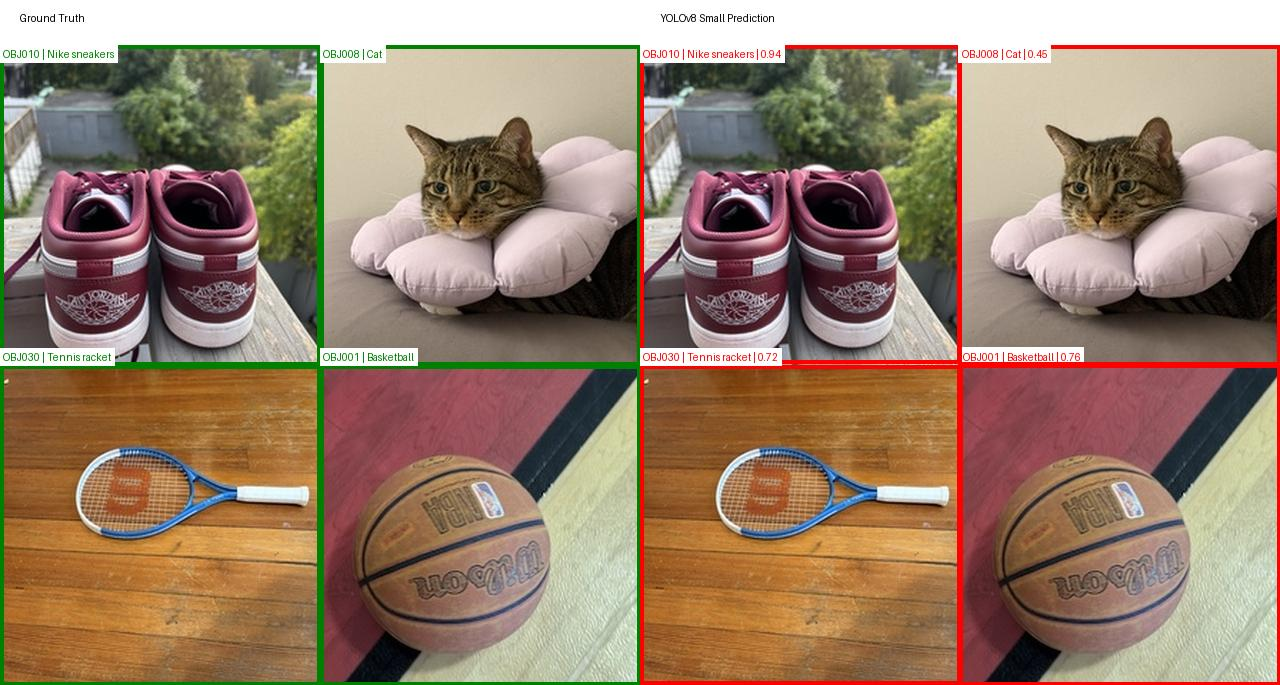


test_000008.jpg


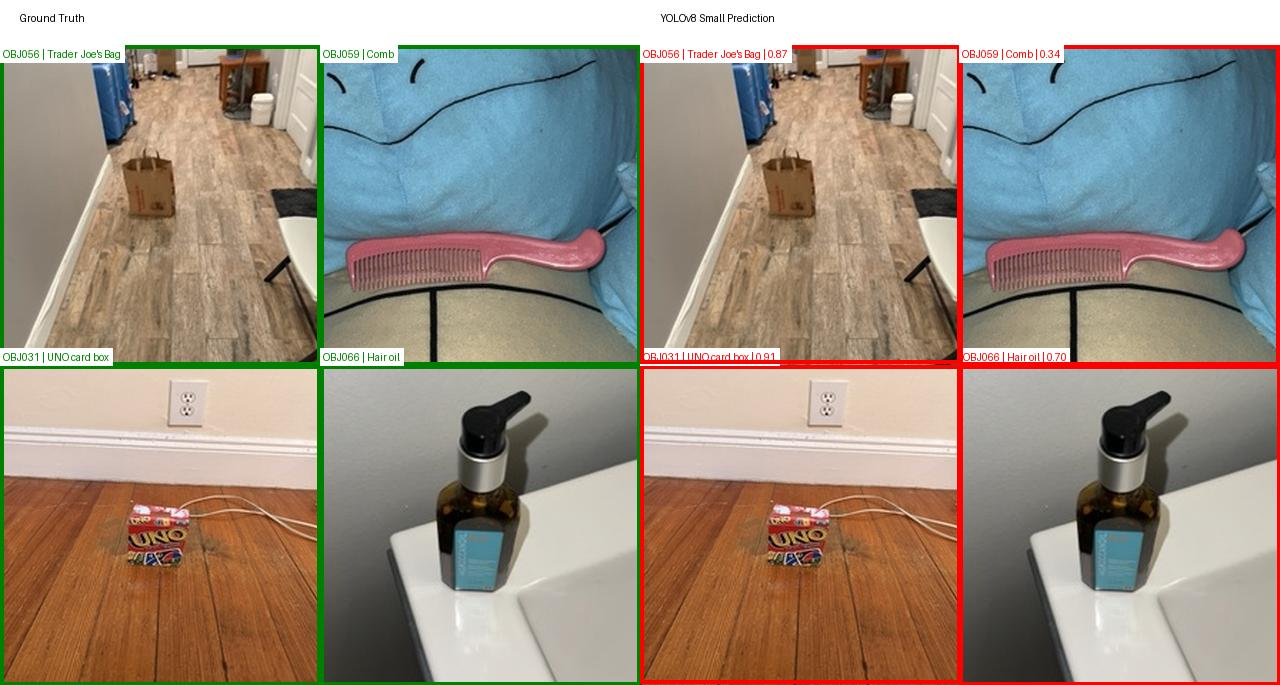


test_000013.jpg


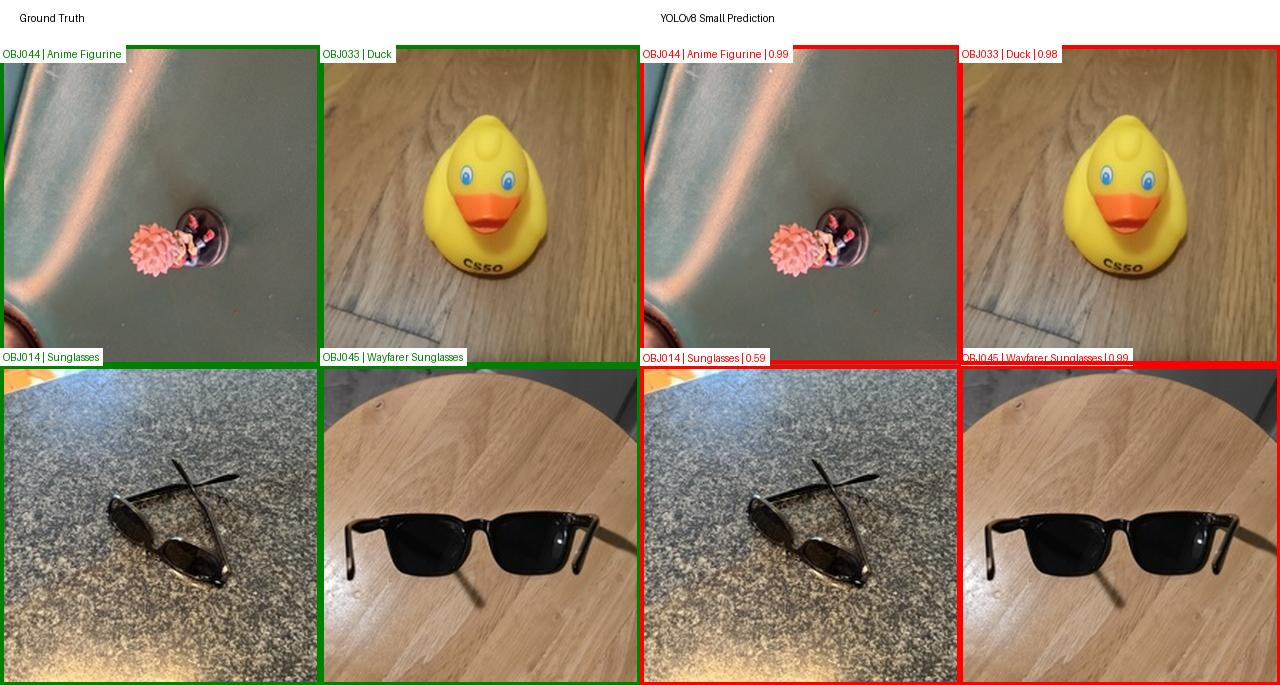


test_000059.jpg


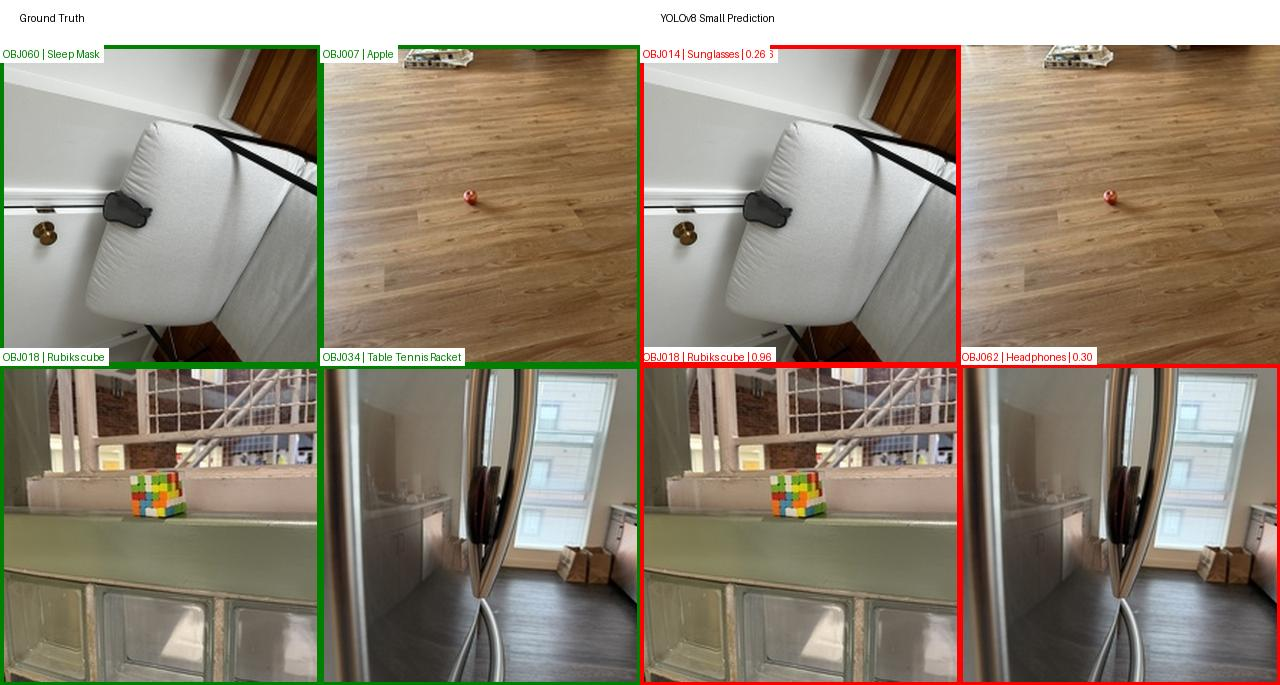

In [39]:
report_figures = []

for image_name in selected_report_images:
    output_path = create_comparison_figure(image_name)

    report_figures.append(output_path)

    print(f"\n{image_name}")
    display(Image.open(output_path))

## 25. Qualitative Analysis

The selected examples show both the strengths and limitations of the final detector.

Three held-out test images achieved perfect 4/4 detection under the evaluation criterion of correct class assignment and IoU ≥ 0.50. These examples demonstrate that the trained YOLOv8 Small model can correctly identify and localize multiple object classes within the same composite image.

A representative failure case is also included. In this example, some objects are correctly detected while others are missed or incorrectly classified.

The failure cases are consistent with the quantitative test results, particularly the recall of 0.7856, and indicate that performance varies across object classes despite strong overall test mAP.

## 26. Save Final Model and Experiment Artifacts

The final model, evaluation outputs, and report-ready figures are preserved before the Colab runtime ends.

The following artifacts are retained:

- Best YOLOv8 Small model checkpoint
- Training metrics and plots
- Final held-out test evaluation outputs
- Report-ready qualitative figures
- Final notebook, downloaded separately from Google Colab

In [40]:
from pathlib import Path
import shutil

PROJECT_ROOT = Path.cwd()

EXPORT_DIR = PROJECT_ROOT / "milestone2" / "final_artifacts"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Export directory:")
print(EXPORT_DIR)

Export directory:
/content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts


In [41]:
# ---------------------------------------------------------
# 1. Best final model
# ---------------------------------------------------------

best_model_source = (
    PROJECT_ROOT
    / "milestone2"
    / "results"
    / "runs"
    / "yolov8s_final_50epochs"
    / "weights"
    / "best.pt"
)

best_model_destination = EXPORT_DIR / "yolov8s_best.pt"

shutil.copy2(
    best_model_source,
    best_model_destination
)

print("Saved:", best_model_destination)

Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts/yolov8s_best.pt


In [42]:
# ---------------------------------------------------------
# 2. Preserve YOLOv8 Small training results
# ---------------------------------------------------------

training_run_dir = (
    PROJECT_ROOT
    / "milestone2"
    / "results"
    / "runs"
    / "yolov8s_final_50epochs"
)

print("Training run directory:")
print(training_run_dir)

# Verify which files were actually created by Ultralytics.
print("\nTraining run artifacts:")
print("-" * 60)

if training_run_dir.exists():
    for path in sorted(training_run_dir.iterdir()):
        if path.is_file():
            print(path.name)
else:
    raise FileNotFoundError(
        f"Training run directory not found: {training_run_dir}"
    )

# Files we want to preserve for the final report and analysis.
files_to_copy = [
    "results.csv",
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
]

print("\nCopying training artifacts:")
print("-" * 60)

copied_training_files = []
missing_training_files = []

for filename in files_to_copy:
    source = training_run_dir / filename

    if source.exists():
        destination = EXPORT_DIR / filename

        shutil.copy2(
            source,
            destination
        )

        copied_training_files.append(filename)
        print(f"Saved: {destination}")
    else:
        missing_training_files.append(filename)
        print(f"Not found: {filename}")

print("\nTraining artifact summary")
print("-" * 60)
print(f"Copied: {len(copied_training_files)}")
print(f"Missing: {len(missing_training_files)}")

if missing_training_files:
    print("\nMissing files:")
    for filename in missing_training_files:
        print(f"- {filename}")

Training run directory:
/content/IE7615-Deep-Learning-for-AI/milestone2/results/runs/yolov8s_final_50epochs

Training run artifacts:
------------------------------------------------------------
BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch720.jpg
train_batch721.jpg
train_batch722.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg

Copying training artifacts:
------------------------------------------------------------
Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts/results.csv
Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts/results.png
Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts/confusion_matrix.png
Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts/confusion_matrix_normalized.png
Sav

In [43]:
# ---------------------------------------------------------
# 3. Preserve final held-out test evaluation artifacts
# ---------------------------------------------------------

test_run_dir = (
    PROJECT_ROOT
    / "milestone2"
    / "results"
    / "runs"
    / "yolov8s_final_test"
)

test_export_dir = EXPORT_DIR / "test_evaluation"
test_export_dir.mkdir(parents=True, exist_ok=True)

print("Test evaluation directory:")
print(test_run_dir)

print("\nTest evaluation artifacts:")
print("-" * 60)

if test_run_dir.exists():
    test_files = [
        path
        for path in sorted(test_run_dir.iterdir())
        if path.is_file()
    ]

    for path in test_files:
        print(path.name)

    print("\nCopying test evaluation artifacts:")
    print("-" * 60)

    copied_test_files = []

    for source in test_files:
        destination = test_export_dir / source.name

        shutil.copy2(
            source,
            destination
        )

        copied_test_files.append(source.name)
        print(f"Saved: {destination}")

    print("\nTest artifact summary")
    print("-" * 60)
    print(f"Copied: {len(copied_test_files)}")

else:
    raise FileNotFoundError(
        f"Test evaluation directory not found: {test_run_dir}"
    )

Test evaluation directory:
/content/IE7615-Deep-Learning-for-AI/milestone2/results/runs/yolov8s_final_test

Test evaluation artifacts:
------------------------------------------------------------
BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg

Copying test evaluation artifacts:
------------------------------------------------------------
Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts/test_evaluation/BoxF1_curve.png
Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts/test_evaluation/BoxPR_curve.png
Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts/test_evaluation/BoxP_curve.png
Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts/test_evaluation/BoxR_curve.png
Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/f

In [44]:
# ---------------------------------------------------------
# 4. Preserve report-ready qualitative figures
# ---------------------------------------------------------

report_export_dir = EXPORT_DIR / "report_figures"
report_export_dir.mkdir(parents=True, exist_ok=True)

print("Report figure source directory:")
print(REPORT_FIGURE_DIR)

print("\nCopying report-ready figures:")
print("-" * 60)

copied_report_figures = []

if REPORT_FIGURE_DIR.exists():
    for figure_path in sorted(REPORT_FIGURE_DIR.glob("*.jpg")):
        destination = report_export_dir / figure_path.name

        shutil.copy2(
            figure_path,
            destination
        )

        copied_report_figures.append(figure_path.name)
        print(f"Saved: {destination}")

    print("\nReport figure summary")
    print("-" * 60)
    print(f"Copied: {len(copied_report_figures)}")

    if len(copied_report_figures) == 0:
        print("WARNING: No report-ready JPG figures were found.")

else:
    raise FileNotFoundError(
        f"Report figure directory not found: {REPORT_FIGURE_DIR}"
    )

Report figure source directory:
/content/IE7615-Deep-Learning-for-AI/milestone2/results/report_figures

Copying report-ready figures:
------------------------------------------------------------
Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts/report_figures/test_000007_comparison.jpg
Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts/report_figures/test_000008_comparison.jpg
Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts/report_figures/test_000013_comparison.jpg
Saved: /content/IE7615-Deep-Learning-for-AI/milestone2/final_artifacts/report_figures/test_000059_comparison.jpg

Report figure summary
------------------------------------------------------------
Copied: 4


In [45]:
# ---------------------------------------------------------
# 5. Verify final exported artifacts
# ---------------------------------------------------------

print("\nFINAL ARTIFACT VERIFICATION")
print("=" * 70)

exported_files = [
    path
    for path in sorted(EXPORT_DIR.rglob("*"))
    if path.is_file()
]

for path in exported_files:
    size_mb = path.stat().st_size / (1024 * 1024)

    print(
        f"{path.relative_to(EXPORT_DIR)} "
        f"({size_mb:.2f} MB)"
    )

print("\nSummary")
print("-" * 70)
print(f"Total exported files: {len(exported_files)}")

# Critical files that must exist.
required_files = [
    EXPORT_DIR / "yolov8s_best.pt",
    EXPORT_DIR / "results.csv",
    EXPORT_DIR / "results.png",
    EXPORT_DIR / "confusion_matrix.png",
    EXPORT_DIR / "confusion_matrix_normalized.png",
]

missing_required_files = [
    path
    for path in required_files
    if not path.exists()
]

if missing_required_files:
    print("\nERROR: Missing required artifacts:")
    for path in missing_required_files:
        print(f"- {path.name}")

    raise FileNotFoundError(
        "Required final artifacts are missing."
    )

report_figures_found = list(
    (EXPORT_DIR / "report_figures").glob("*.jpg")
)

if len(report_figures_found) < 4:
    raise FileNotFoundError(
        "Expected at least four report-ready figures."
    )

print("\nAll required final artifacts are present.")


FINAL ARTIFACT VERIFICATION
BoxF1_curve.png (0.71 MB)
BoxPR_curve.png (0.08 MB)
BoxP_curve.png (0.55 MB)
BoxR_curve.png (0.55 MB)
confusion_matrix.png (0.50 MB)
confusion_matrix_normalized.png (0.50 MB)
report_figures/test_000007_comparison.jpg (0.14 MB)
report_figures/test_000008_comparison.jpg (0.11 MB)
report_figures/test_000013_comparison.jpg (0.13 MB)
report_figures/test_000059_comparison.jpg (0.11 MB)
results.csv (0.01 MB)
results.png (0.23 MB)
test_evaluation/BoxF1_curve.png (0.68 MB)
test_evaluation/BoxPR_curve.png (0.08 MB)
test_evaluation/BoxP_curve.png (0.55 MB)
test_evaluation/BoxR_curve.png (0.50 MB)
test_evaluation/confusion_matrix.png (0.50 MB)
test_evaluation/confusion_matrix_normalized.png (0.50 MB)
test_evaluation/val_batch0_labels.jpg (0.69 MB)
test_evaluation/val_batch0_pred.jpg (0.69 MB)
test_evaluation/val_batch1_labels.jpg (0.70 MB)
test_evaluation/val_batch1_pred.jpg (0.69 MB)
test_evaluation/val_batch2_labels.jpg (0.72 MB)
test_evaluation/val_batch2_pred.jpg (

In [46]:
import shutil

archive_path = shutil.make_archive(
    base_name=str(
        PROJECT_ROOT
        / "milestone2_final_artifacts"
    ),
    format="zip",
    root_dir=EXPORT_DIR
)

print("Created archive:")
print(archive_path)

Created archive:
/content/IE7615-Deep-Learning-for-AI/milestone2_final_artifacts.zip


In [47]:
from google.colab import files

files.download(
    str(
        PROJECT_ROOT
        / "milestone2_final_artifacts.zip"
    )
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>